In [1]:
import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches
import xpart as xp
import xobjects as xo
import math

import useful_functions

In [2]:
#Pre-defined params
# %% create environment, parameters and first simple cells & structures
#reupload

pdr = xt.Environment()
pdr.particle_ref = xt.Particles(kinetic_energy0=2.86e9, mass0 = xt.ELECTRON_MASS_EV)

E0 = 2.86e9; VRF = 2.000e6 # beam energy in eV and RF voltage (1 cavity) in V

pdr.vars({ 
'l_cell':   3.5000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5250,
'dl_drift':  -0.1500,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   3.0000,
'l_trips':   0.4000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.8579,
'kQDarc':  -2.8333,
'kQFarcM':   2.7633,
'kQDarcM':  -3.1990,
'kQFDS':   2.8473,
'kQDDS':  -2.5869,
'kQFDoub':   3.7011,
'kQDDoub':  -2.3242,
'kQFtr':   4.1683,
'kQDtr':  -2.5106,
'l_sext':   0.1000,
'kSF':  80.5236,
'kSD': -114.8259,})

pdr.vars({'N_cells_S': 8,'hBarc' : '6.283185307/(6*(2*N_cells_S*l_bend + l_bendDS))',
  'kQFarc': 2.9478, 'kQDarc':-2.9231,'kQFarcM': 2.8846, 'kQDarcM':-2.7567, 
  'kQFDS': 2.8042, 'kQDDS':-2.2858, 'kQFDoub': 3.9170, 'kQDDoub':-2.5190, 
  'kQFtr': 4.4429, 'kQDtr':-2.4723 } )

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

pdr.new('Bend', xt.Bend, length='l_bend', angle='hBarc*l_bend', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bend/2', edge_exit_angle='hBarc*l_bend/2')
pdr.new('QFarc',  xt.Quadrupole, length='l_quad',    k1='kQFarc' )
pdr.new('QFarcH', xt.Quadrupole, length='l_quad/2.', k1='kQFarc' )
pdr.new('Drarc',  xt.Drift,      length='l_drift' )
pdr.new('DrarcS', xt.Drift,      length='l_drift + dl_drift' )
pdr.new('QDarc',  xt.Quadrupole, length='l_quad',    k1='kQDarc' )
pdr.new('QFarcM', xt.Quadrupole, length='l_quad',    k1='kQFarcM' )
pdr.new('QDarcM', xt.Quadrupole, length='l_quad',    k1='kQDarcM' )
pdr.new('BendDS', xt.Bend, length='l_bendDS', angle='hBarc*l_bendDS', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bendDS/2', edge_exit_angle='hBarc*l_bendDS/2')
pdr.new('QFDS',   xt.Quadrupole, length='l_quad',    k1='kQFDS' )
pdr.new('QDDS',   xt.Quadrupole, length='l_quad',    k1='kQDDS' )
pdr.new('DrDSL',  xt.Drift,      length='2*l_drift + l_bend + dl_noben' )
pdr.new('DrTrans',xt.Drift,      length='l_drift + dl_trans' )
pdr.new('QFDoub', xt.Quadrupole, length='l_quad',    k1='kQFDoub' )
pdr.new('QDDoub', xt.Quadrupole, length='l_quad',    k1='kQDDoub' )
pdr.new('DrDoub', xt.Drift,      length='l_doub' )

pdr.new('QFtr',    xt.Quadrupole, length='l_quad',    k1='kQFtr' )
pdr.new('QFtrH',   xt.Quadrupole, length='l_quad/2.', k1='kQFtr' )
pdr.new('QDtr',    xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('QDtrH',   xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('DrTripl', xt.Drift,      length='l_tripl' )
pdr.new('DrTrips', xt.Drift,      length='l_trips' )

#Add any new variables and structures here


pdr.new('Drarc2', xt.Drift, length='(l_drift-l_sext)/2')
pdr.new('Drarc3', xt.Drift, length='((l_drift-l_sext)/2)+l_sext')
pdr.new('SFDS', xt.Sextupole, length='l_sext',k2='kSF')
pdr.new('SDDS', xt.Sextupole, length='l_sext',k2='kSD')

'SDDS'

/home/mwatson/.local/lib/python3.12/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


3.5
3.5
4.7


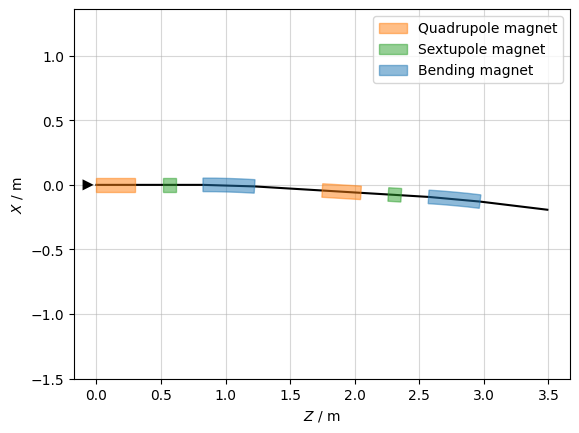

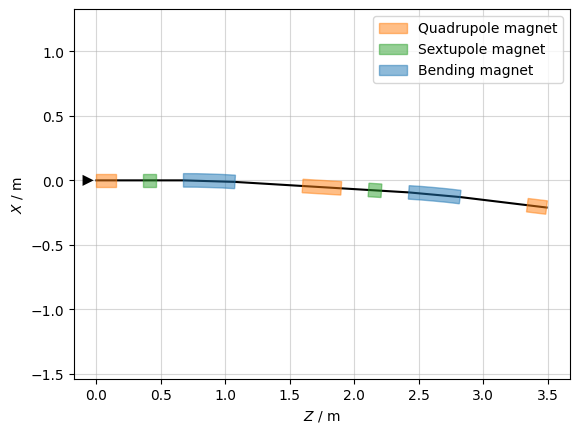

In [3]:
# just an arc cell
cell_arcS = pdr.new_line( length='l_cell', 
    components =[ 
    pdr.new('QF_cell_arc',    'QFarc',at='0*l_drift + 0.5*l_quad + 0.0*l_bend'),
    pdr.new('SF_cell_arc','SFDS', at='l_quad+(l_drift-l_sext)/2+0.5*l_sext'),
    pdr.new('Bend1_cell_arc', 'Bend', at='1*l_drift + 1.0*l_quad + 0.5*l_bend'),
    pdr.new('QD_cell_arc',    'QDarc',at='2*l_drift + 1.5*l_quad + 1.0*l_bend'),
    pdr.new('SD_cell_arc','SDDS',at='2*l_drift+2*l_quad+l_bend+l_drift/2'),
    pdr.new('Bend2_cell_arc', 'Bend', at='3*l_drift + 2.0*l_quad + 1.5*l_bend'),
    ])
cell_arcS.survey().plot()
print(cell_arcS.get_length())
cell_arc = pdr.new_line( components = [ 
   pdr.new('QF_cell_arcH1',  'QFarcH' ), pdr.place( 'Drarc2' ),
   pdr.new('SF_cell_arc1', 'SFDS'), pdr.place('Drarc2'),
   pdr.new('Bend1_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QD_cell_arcH',   'QDarc' ),  pdr.place( 'Drarc2' ),
   pdr.new('SD_cell_arc1', 'SDDS'), pdr.place('Drarc2'),
   pdr.new('Bend2_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QF_cell_arcH2',  'QFarcH' ), 
   ])
cell_arc.survey().plot()
print(cell_arc.get_length())
# triplet starting with 
cell_tr = pdr.new_line(
    components = [
    pdr.new('QF_cell_trH1', 'QFtrH',    at='0*l_trips + 0.25*l_quad + 0.0*l_tripl'),
    pdr.new('QD_cell_tr1',  'QDtr',     at='1*l_trips + 1.00*l_quad + 0.0*l_tripl'),
    pdr.new('Mkr_cell_tr',   xt.Marker, at='1*l_trips + 1.50*l_quad + 0.5*l_tripl'),
    pdr.new('QD_cell_tr2',  'QDtr',     at='1*l_trips + 2.00*l_quad + 1.0*l_tripl'),
    pdr.new('QF_cell_trH2', 'QFtrH',    at='2*l_trips + 2.75*l_quad + 1.0*l_tripl')
    ])

print(cell_tr.get_length())

In [4]:
#makesextant function
def makesextant ( name, fall ):
    comps = [ ]
    comps = comps + [pdr.new('Drarc0_'+name+str(0),'Drarc2'),pdr.new('SFA0_'+name+str(0),'SFDS')]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       comps = comps + [ pdr.new('Drarc1_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc2_'+ name + str(ind+1), 'Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [pdr.new('Drarc3_'+name+str(ind+1),'Drarc2'),pdr.new('SDA_'+name+str(ind+1),'SDDS')]
       comps = comps + [ pdr.new('Drarc4_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc5_'+ name + str(ind+1), 'Drarc'), pdr.new('QFA_' + name + str(ind), 'QFarc')]
       comps = comps + [pdr.new('Drarc6_'+name+str(ind+1),'Drarc2'),pdr.new('SFA_'+name+str(ind+1),'SFDS')]
    # Replace last QF and add last arc cell (matching quads) "by hand"
    comps[-3] = pdr.new('QFAM_' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps = comps + [pdr.new('DrarcS1_'+ name + str(ind+1), 'Drarc2'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.new('Drarc7_'+ name + str(ind+1), 'Drarc'), pdr.new('QDAM_' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.new('Drarc75_'+name+str(ind+1),'Drarc2'),pdr.new('SDAM_'+name+str(ind+1),'SDDS')]
    comps = comps + [pdr.new('Drarc8_'+ name + str(ind+1), 'Drarc2'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]
    # Add dispersion suppressor
    comps = comps + [pdr.new('Drarc9_'+ name + str(ind+1), 'Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.new('DrDSL1_'+ name + str(ind+1), 'DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.new('Drarc10_'+ name + str(ind+1), 'Drarc'), pdr.new('BendDS_' + name, 'BendDS')]
    # Add doublet matching 
    comps = comps + [pdr.new('DrTrans1_'+ name + str(ind+1), 'DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.new('DrDoub1_'+ name + str(ind+1), 'DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.new('DrTripl1_'+ name + str(ind+1), 'DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  
    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]
    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )
    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()
    return pdr.new_line( components = comps )

Slicing line: 100%|██████████| 109/109 [00:00<00:00, 140497.58it/s]
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


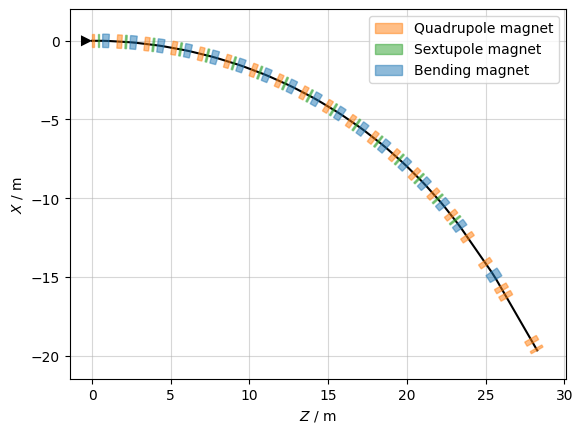

In [5]:
arc1R = makesextant( 'xR', 'symm' )
arc1R_sliced = arc1R.select()
arc1R_sliced.cut_at_s( np.linspace(.05, arc1R.get_length()-.05, int(arc1R.get_length()/.05-.5)) )
arc1R.insert( pdr.new('CtrS1_xR1', xt.Marker ), at='(l_tripl+l_quad)/2', from_='QDDoub_xR' )
arc1R.survey().plot()

In [6]:
# %% Routine for several matchings in a row for 90 degrees arc cells and given tunes

# Matching of arc cell
cell_arc_opt = cell_arc.match( method='4d', solve=True, verbose=False,
    vary=[
        xt.VaryList(['kQFarc', 'kQDarc', 'kQFarcM'], step=1e-4),    ],
    targets=[
        xt.TargetSet(qx=0.25, qy=0.25, tol=1.0e-6, tag='end'), # just twice the same 
        xt.TargetSet(mux=0.25, muy=0.25, at=xt.END, tol=1.0e-6)]  )

# Triplet cell to chosen betatron functions
cell_tr_opt = cell_tr.match( method='4d', solve=True,
    vary=[ # use individual Vary commands instead of List for arc cell
        xt.Vary('kQFtr', step=1e-4 ),
        xt.Vary('kQDtr', step=1e-4),    ],
    targets=[
        xt.TargetSet(betx=2.50, bety=2.50, at='Mkr_cell_tr', tol=1.0e-6, tag='betas')] )


# Matching sequence with ring working as (one of the) target(s)



cell_tr_tw = cell_tr.twiss(method='4d')
mid_idx = len(cell_tr_tw.betx) // 2
betxS = cell_tr_tw.betx[mid_idx]
betyS = cell_tr_tw.bety[mid_idx]
useful_functions.matchingBeta( betxS, betyS,cell_arc_opt, cell_tr_opt,cell_arc,cell_tr,arc1R)



                                             07              
Optimize - start penalty: 0.8838                            
Matching: model call n. 21 penalty = 2.0237e-09              
Optimize - end penalty:  2.02373e-09                            
                                             07              
Optimize - start penalty: 0                                  
Matching: model call n. 23 penalty = 0.0000e+00              
Optimize - end penalty:     0                            
                                             
Optimize - start penalty: 7.406                             
Matching: model call n. 78 penalty = 4.7289e-10              
Optimize - end penalty:  4.72887e-10                            
                                             
Optimize - start penalty: 4.729e-10                          
Matching: model call n. 80 penalty = 4.7289e-10              
Optimize - end penalty:  4.72887e-10                            


Slicing line: 100%|██████████| 648/648 [00:00<00:00, 200332.35it/s]


Horizontal Chromaticity (dqx): 0.9600
Vertical Chromaticity (dqy):   -1.0247
Max Betx: 8.47 m
Max Bety: 9.92 m


TypeError: matchingWP() missing 3 required positional arguments: 'cell_arc_opt', 'cell_arc', and 'arc1R'

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


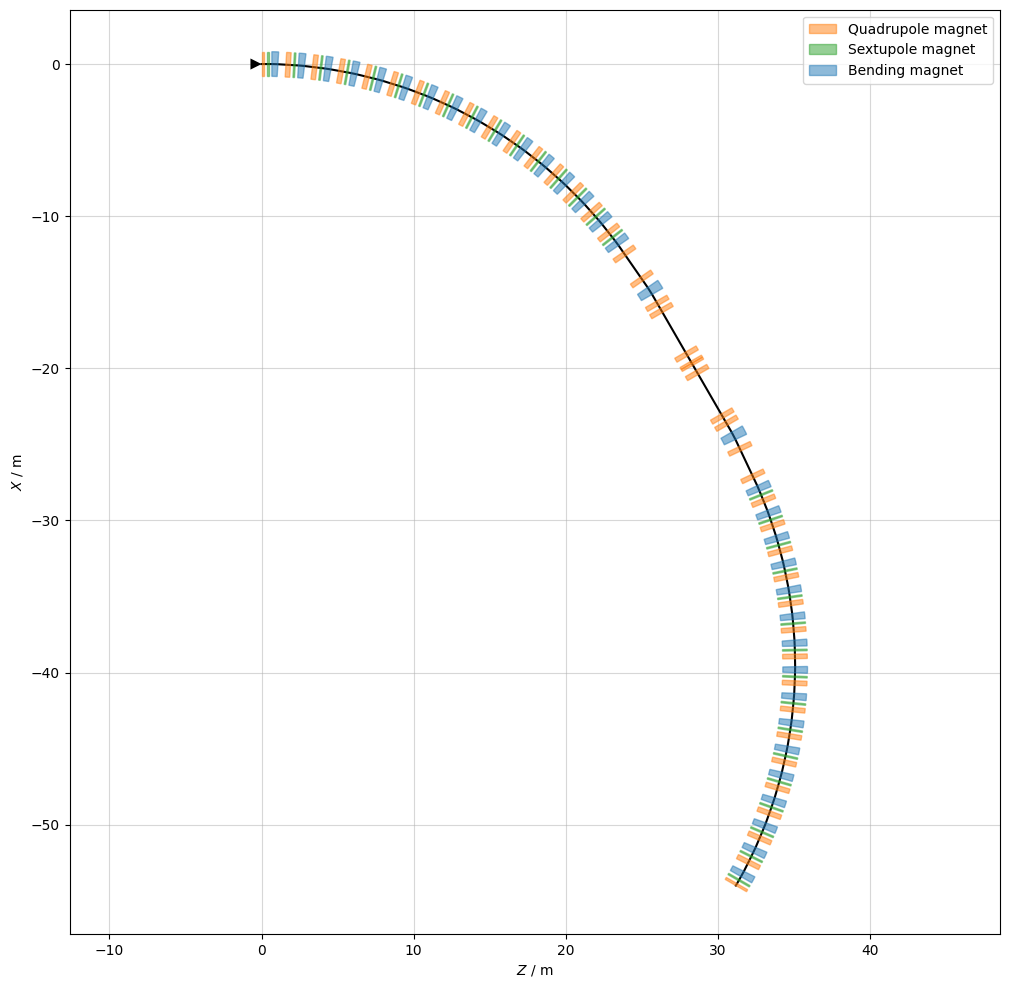

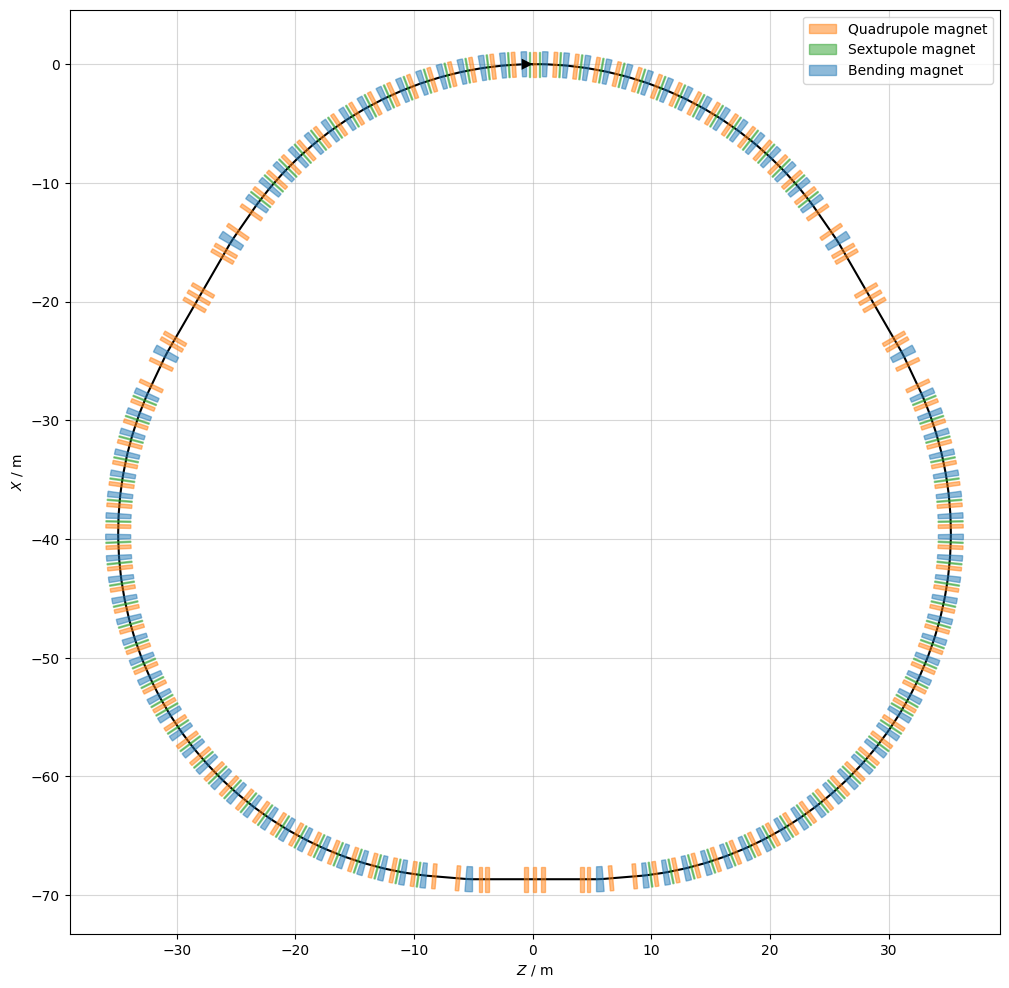

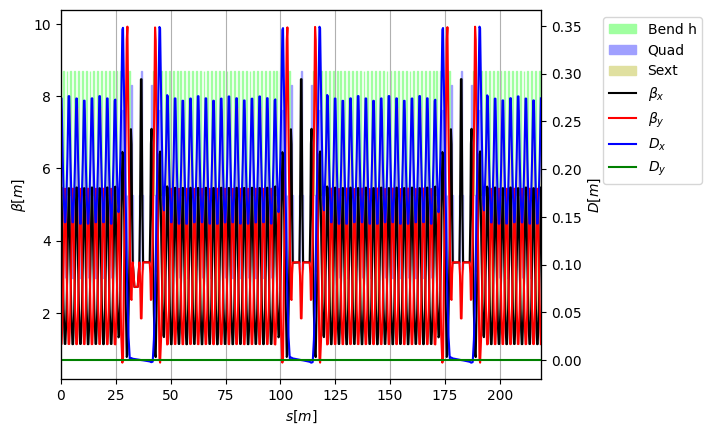

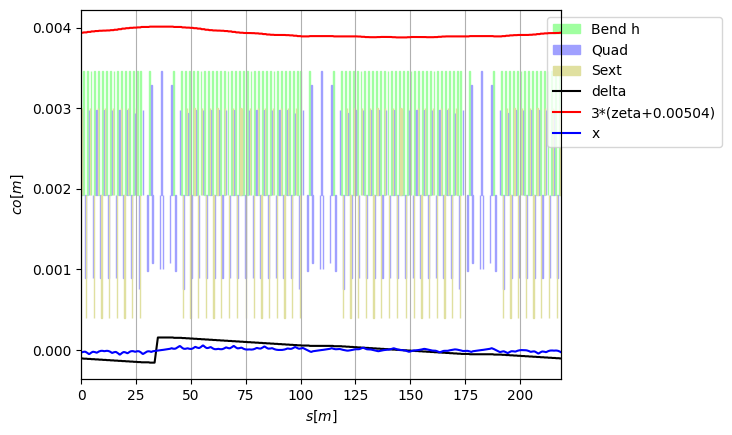

In [7]:
# One period from center of arc to center of arc
plt.rcParams['figure.figsize'] = [12,12]
period = makesextant( 'PR', 'symm') + ( -makesextant( 'PL', 'symm') )
period.survey().plot()
period_sliced = period.select()
period_sliced.cut_at_s( np.linspace(.05, period.get_length()-.05, int(period.get_length()/.05-.5)) )

# Full ring without X-poles, RF and wigglers
ring  = makesextant( '1R', 'right') + makesextant( '2L', 'left') + makesextant( '2R', 'right') + makesextant( '3L', 'left') + makesextant( '3R', 'right') + makesextant( '1L', 'left')



#useful_functions.ChromCorrect(ring,'kSF', 'kSD')
#useful_functions.SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 10.), (0., 1.), .08, "Standard.pdf" )



fRev = 1./(ring.twiss(method='4d').T_rev0)
fRF  = fRev*round(4.e8/fRev)  # at integer harmonics and close to 400 MHz
pdr.new('RFCav',  xt.Cavity, length=1.5, frequency=fRF, voltage=VRF, 
        lag=(180/np.pi)*(np.pi - np.arcsin(U0/VRF)) - 1.8 ) 
ring.insert( pdr.new('RFCav_1', 'RFCav'), at='(l_tripl+l_quad)/2', from_='QDDoub_1R' )
ring.configure_radiation(model='mean')
ring.configure_bend_model(edge='full')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True )
print(f"Horizontal Chromaticity (dqx): {ring_tw.dqx:.4f}")
print(f"Vertical Chromaticity (dqy):   {ring_tw.dqy:.4f}")
print(f"Max Betx: {max(ring_tw.betx):.2f} m")
print(f"Max Bety: {max(ring_tw.bety):.2f} m")

ring.survey().plot()



ring_tw.plot()
ring_tw.plot('delta 3*(zeta+0.00504) x')
#useful_functions.matchingWP( ring_tw.qx, ring_tw.qy,cell_arc_opt, cell_tr_opt,cell_arc,cell_tr,arc1RMakePlot=False )
def ChromCorrect(ksf, ksd, MakePlot=False):
        
    opt_chrom = ring.match(
        solve=True,
        verbose=False,
        method='6d',
        vary=xt.VaryList([ksf, ksd], step=1e-3),
        targets=xt.TargetSet(dqx=0., dqy=0., tol=1e-3))
    opt_chrom.target_status()
    opt_chrom.run_jacobian(n_steps=100)
    opt_chrom.target_status()
    # Print the final matched strengths

    print(f"Matched kSF: {pdr.vars['kSF']._get_value():.6f}")
    print(f"Matched kSD: {pdr.vars['kSD']._get_value():.6f}")   

useful_functions.ChromCorrect(ksf,ksd)

print( f'\nApproximatif harmonics {fRF/fRev:10.5f} and fRF ={fRF:8.5f}' )
# print( ring_tw.keys() )
print( f"  Length of short drifts: {pdr['l_drift']:7.3f} m" )
# print( ring_tw.keys() )
print( f'=>Circumference {ring_tw.circumference:8.4f} and revolution {1e6*ring_tw.T_rev0:8.5f} us' )
print( f'  Energy loss per turn from me {U0:10.2f} and twiss' + 
       f'  {ring_tw.eneloss_turn:10.2f} and diff {ring_tw.eneloss_turn-U0:10.2f}' )
print( f'  Vertical damping time {1/ring_tw.damping_constants_turns[1]:10.3f} and {2*E0/ring_tw.eneloss_turn:10.3f} turns' )
print( f'  Working point{ring_tw.qx:10.5f} and{ring_tw.qy:10.5f}')
print( f'  Equilibrium emmittances{ring_tw.eq_gemitt_x:10.3e},{ring_tw.eq_gemitt_y:10.3e} and{ring_tw.eq_gemitt_zeta:10.3e}'  )
print( f'  Equilibrium polarization{ring_tw.spin_polarization_eq:8.5f} and time {ring_tw.spin_t_pol_buildup_s:10.2f} s')

def plot_working_point(qx, qy, max_order=4):
    fig, ax = plt.subplots(figsize=(8, 8))
    drawn_lines = set()

    for order in range(1, max_order + 1):
        linewidth = 2.0 / order
        alpha = 1.0 / order
        
        for m in range(order + 1):
            n = order - m
            for p in range(-max_order, max_order * 2):
                
                common = math.gcd(m, n, p)
                if common == 0: continue 
                
                line_id = (m // common, n // common, p // common)
                
                if line_id not in drawn_lines:
                    if n != 0:
                        x = np.array([0, 1])
                        y = (p - m * x) / n
                        if np.any((y >= 0) & (y <= 1)) or np.any((y <= 0) & (y >= 1)):
                            ax.plot(x, y, 'k-', lw=linewidth, alpha=alpha)
                    elif m != 0:
                        x_pos = p / m
                        if 0 <= x_pos <= 1:
                            ax.axvline(x_pos, color='k', lw=linewidth, alpha=alpha)
                    
                    drawn_lines.add(line_id)

    # Plot the specific working point
    ax.plot(qx % 1, qy % 1, 'ro', ms=10, label=f'WP ({qx:.4f}, {qy:.4f})')
    
    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'Tune Diagram - Order 1 to {max_order}')
    ax.set_xlabel('$Q_x$ fraction')
    ax.set_ylabel('$Q_y$ fraction')
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend()
    
    plt.show()
plot_working_point(ring_tw.qx,ring_tw.qy)

Slicing line: 100%|██████████| 218/218 [00:00<00:00, 4345.81it/s]


'l_cell':   3.5000,
'l_bend':   0.4000,
'l_bendDS':   0.5500,
'dl_noben':   0.2500,
'l_quad':   0.3000,
'l_drift':   0.5250,
'dl_drift':  -0.1500,
'dl_trans':   0.0000,
'l_doub':   0.2500,
'l_tripl':   3.0000,
'l_trips':   0.4000,
'N_cells_S':   8.0000,
'hBarc':   0.1507,
'kQFarc':   2.8579,
'kQDarc':  -2.8333,
'kQFarcM':   2.7633,
'kQDarcM':  -3.1990,
'kQFDS':   2.8473,
'kQDDS':  -2.5869,
'kQFDoub':   3.7010,
'kQDDoub':  -2.3241,
'kQFtr':   4.1682,
'kQDtr':  -2.5105,
'l_sext':   0.1000,
'kSF':  80.5236,
'kSD': -114.8259,
  Name        Type      L(m)     sin(m)   sout(m)  driftl  driftr    k1(1/m^2)
  QFA_PRCH    Quadrupo  0.1500   0.0000   0.1500   0.0000  0.2125 'kQFarc' =  2.8579  
  SFA0_PR0    Sextupol  0.1000   0.3625   0.4625   0.2125  0.2125  None    =  0.0000  
  Bend1_PR1   Bend      0.4000   0.6750   1.0750   0.2125  0.5250  None    =  0.0000  
  QDA_PR1     Quadrupo  0.3000   1.6000   1.9000   0.5250  0.2125 'kQDarc' = -2.8333  
  SDA_PR1     Sextupol  0.1000   2.1125   2.2

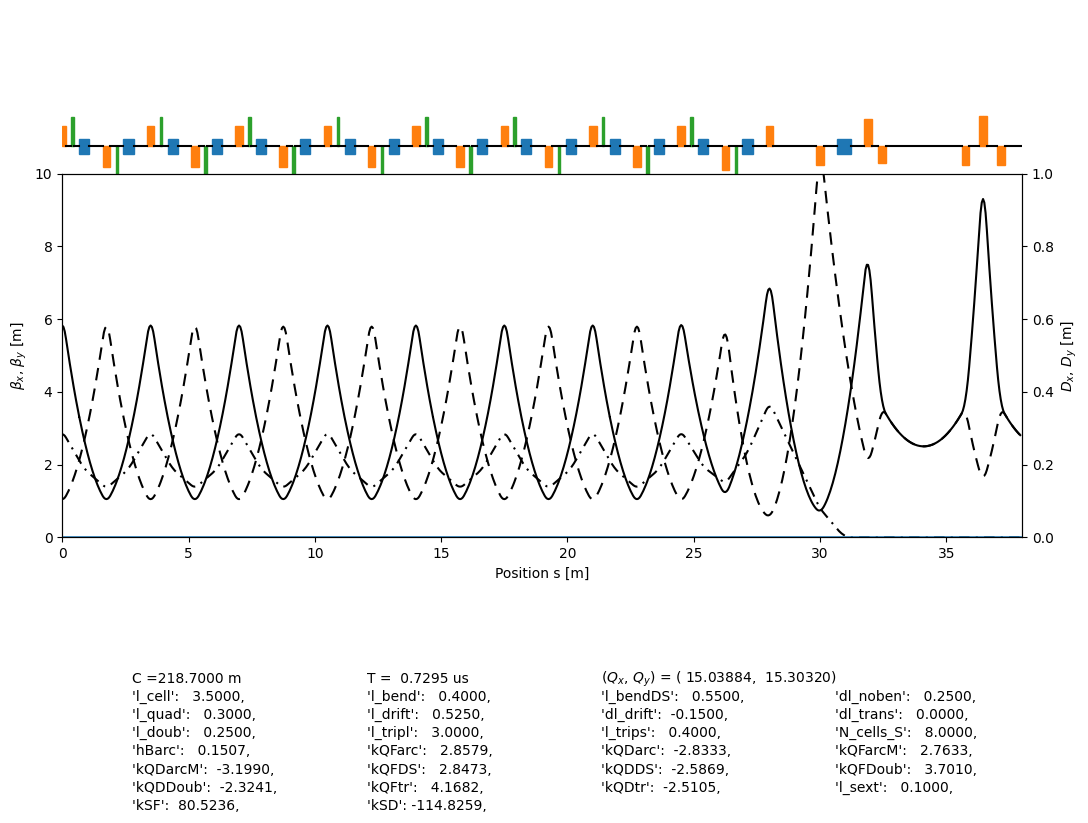

In [ ]:
useful_functions.SpuckParsAus( period_sliced.twiss(method='4d'), period,(0., 38.), (0., 10.), (0., 1.), .08, "Standard.pdf" )

In [ ]:
# %% Simple test of tracking with synchrotron radiation - takes some time
ring.configure_radiation(model='mean')
ring_tw=ring.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True)
#ring_tw.plot()
#print( ring_tw.keys() )
print( f' Energy loss per turn from twiss {ring_tw.eneloss_turn:10.2f} and me {U0:10.2f}')
print( 1/ring_tw.damping_constants_turns )
print( 2*E0/ring_tw.eneloss_turn )

npts = 200
epsx, epsy, epsl = 1.0e-7, 1.0e-7, 1.0e-4  # starting with somewhat large emittances
betxin, alfxin  = ring_tw.betx[0], ring_tw.alfx[0] 
xin, pxin       = ring_tw.x[0], ring_tw.px[0]
dxin, dpxin     = ring_tw.dx[0], ring_tw.dpx[0]
betyin, alfyin  = ring_tw.bety[0], ring_tw.alfy[0] 
yin, pyin       = ring_tw.y[0], ring_tw.py[0]   # should be zero for perfect case
#epsx, epsl      = 2.0*ring_tw.eq_gemitt_x, 2.0*ring_tw.eq_gemitt_zeta
betlin          = ring_tw.bets0
zetain, deltain = ring_tw.zeta[0], ring_tw.delta[0]
print( f'At reference location: D ={dxin:7.4f} m, Dp ={dpxin:7.4f},' +
       f' betx ={betxin:7.4f} m, alfx ={alfxin:7.4f},' + 
       f' betl ={betlin:7.4f} m ')

normat = np.array([
    [(epsx*betxin)**.5,         0,                 0,  0, 0, dxin*(epsl/betlin)**.5],
    [-alfxin*(epsx/betxin)**.5, (epsx/betxin)**.5, 0,  0, 0, dpxin*(epsl/betlin)**.5],
    [0,  0,  (epsx*betyin)**.5,         0,                 0, 0],
    [0,  0,  -alfyin*(epsx/betyin)**.5, (epsx/betyin)**.5, 0, 0],
    [0, 0, 0, 0, (epsl*betlin)**.5, 0                ],
    [0, 0, 0, 0, 0,                 (epsl/betlin)**.5]               
    ])

parts = np.array([
     [xin, pxin, yin, pyin, zetain, deltain] + normat@np.random.randn(6) 
         for ind in range(npts) ]).T
# quit()
p2 = xt.Particles(kinetic_energy0 = 2860.e6, mass0 = xt.ELECTRON_MASS_EV,
                  x    = parts[0], px   = parts[1],
                  y    = parts[2], py   = parts[3],
                  zeta = parts[4], delta = parts[5] )
ring.configure_radiation(model='quantum')
ring.track( p2, num_turns = 6100, turn_by_turn_monitor = True,
            with_progress = True )

data = ring.record_last_track
trnplt = [1, 2000, 4000, 6000]
#trnplt = range( len(data.x.T) ) # superimpose all turns, rendering is slowish
fig = plt.figure( figsize=(14., 4.) )
fig.suptitle( f'Phase Space Plots - particle survival {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
ax = fig.subplots(1, 3)
fig.subplots_adjust( wspace=0.4 )
ax[0].set_xlabel('x (mm)')
ax[0].set_ylabel("x' (mrad)")
ax[1].set_xlabel('y (mm)')
ax[1].set_ylabel("y' (mrad)")
ax[2].set_xlabel('z (mm)')
ax[2].set_ylabel(r'rel. mom. offset ($10^{-3}$)')
for ind in range( len(trnplt) ):  # data.x.T[ind] is nparray (behaviour of multiplication)!
   print( f' ==> Plotting turn"{trnplt[ind]:5d}')
   ax[0].scatter( 1000*(data.x.T[trnplt[ind]] - 1.*ring_tw.dx[0]*data.delta.T[trnplt[ind]]), 
            1000*(data.px.T[trnplt[ind]] - 1.*ring_tw.dpx[0]*data.delta.T[trnplt[ind]]),
            s=.4, c = f'C{ind:1d}')
   ax[1].scatter( 1000*(data.y.T[trnplt[ind]]), 1000*(data.py.T[trnplt[ind]]), 
            s=.2, c = f'C{ind:1d}' )
   ax[2].scatter(1000*data.zeta.T[trnplt[ind]], 1000*data.delta.T[trnplt[ind]], 
            s=.2, color=f'C{ind:1d}' )

print( [pdr['RFCav_1'].lag, pdr['RFCav_1'].voltage] )

print( f' Particle survival: {int(((p2.state + 1)/2).sum()):5d} out of {npts:5d}' )
plt.savefig('Particle_survival.png')

 Energy loss per turn from twiss  892439.35 and me  891804.40
[6588.40754104 6410.54090311 3162.48721838]
6409.399151246342
At reference location: D = 0.2742 m, Dp = 0.1206, betx = 5.4704 m, alfx =-2.3729, betl =14.6628 m 


Tracking:   3%|▎         | 200/6100 [00:12<06:07, 16.06it/s]


KeyboardInterrupt: 

In [ ]:
line = ring  # Assumes 'ring' is your environment from previous cells
line.configure_radiation(model=None) # DA is usually done without radiation or with 'mean'

# Get Twiss and Emittance data
tw = line.twiss6d() 

ex = ring_tw.eq_gemitt_x
ey = ring_tw.eq_gemitt_y


num_turns = 2000 # Increased turns for better accuracy
n_r = 50         # Radial steps
n_theta = 80     # Angular steps

# Generate a polar grid in normalized coordinates (sigmas)
x_norm, y_norm, r_xy, theta_xy = xp.generate_2D_polar_grid(
    r_range=(0, 50),     
    theta_range=(0, np.pi),
    nr=n_r, ntheta=n_theta
)

print(ex,ey)

nemitt_x=line.particle_ref.beta0[0] * line.particle_ref.gamma0[0] * ex,
nemitt_y=line.particle_ref.beta0[0] * line.particle_ref.gamma0[0] * ey

print(nemitt_x,nemitt_y)

2.9490994033977596e-08 9.831181619731314e-57
(0.00016508705440222216,) 5.503377787214614e-53


In [ ]:
# Build and Track Particles
particles = line.build_particles(
    x_norm=x_norm, 
    y_norm=y_norm,
    nemitt_x=13000e-6,
    nemitt_y=12000e-6
)
print(f"Tracking {len(particles.x)} particles for {num_turns} turns...")
'''line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
'''
line.track(particles, num_turns=200, with_progress=True)

# Sort particles back to the original grid order
particles.sort(interleave_lost_particles=True)

# Process the Boundary
turn_lost = particles.at_turn.reshape(n_r, n_theta)
x_grid = x_norm.reshape(n_r, n_theta)
y_grid = y_norm.reshape(n_r, n_theta)

# Find the last surviving particle along each angle (theta)
da_x_sig = []
da_y_sig = []

for i_theta in range(n_theta):
    # Get survival for this specific angle
    alive_indices = np.where(turn_lost[:, i_theta] == num_turns)[0]
    if len(alive_indices) > 0:
        last_idx = alive_indices[-1]
        da_x_sig.append(x_grid[last_idx, i_theta])
        da_y_sig.append(y_grid[last_idx, i_theta])
    else:
        da_x_sig.append(0)
        da_y_sig.append(0)


Tracking 4000 particles for 2000 turns...


Tracking: 100%|██████████| 200/200 [00:09<00:00, 21.91it/s]


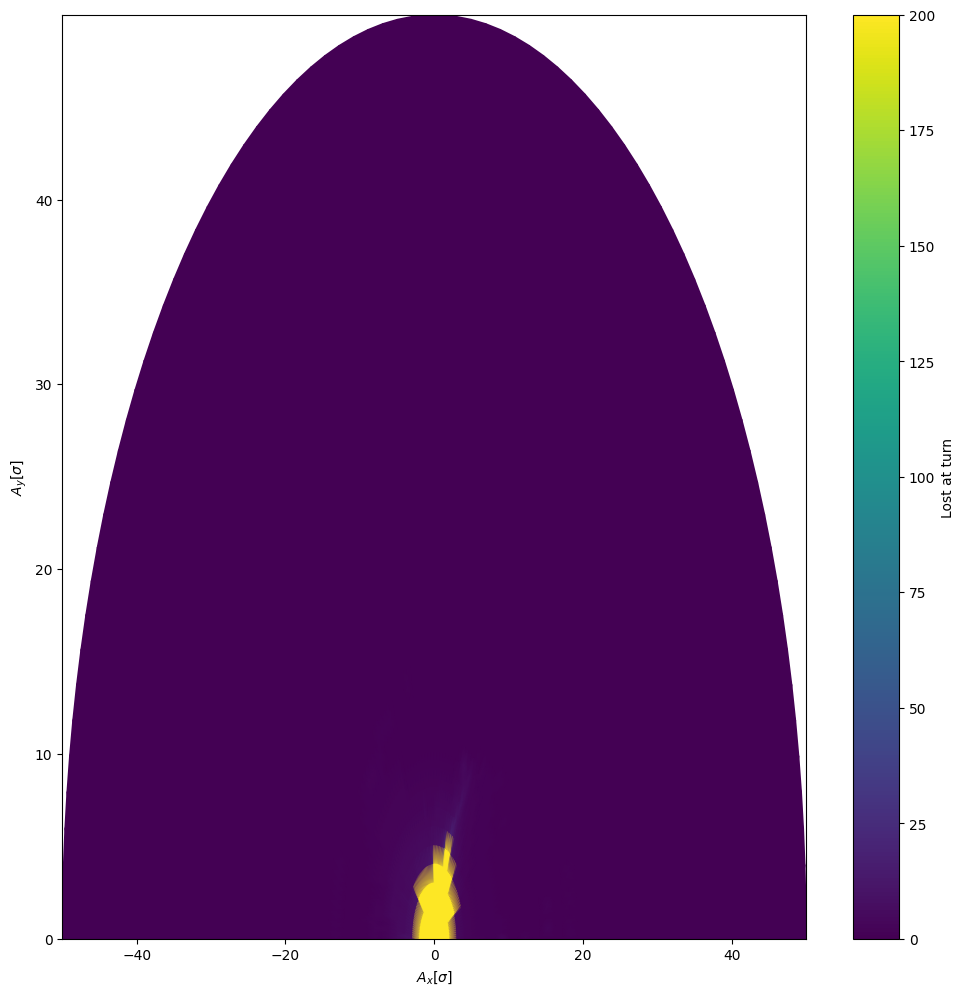

In [ ]:


plt.figure(2)
plt.pcolormesh(
    x_norm.reshape(n_r, n_theta), y_norm.reshape(n_r, n_theta),
    particles.at_turn.reshape(n_r, n_theta), shading='gouraud')
plt.xlabel(r'$A_x [\sigma]$')
plt.ylabel(r'$A_y [\sigma]$')
ax = plt.colorbar()
ax.set_label('Lost at turn')

plt.show()